In [5]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import ast
import torch
import pickle

In [6]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="CUB", return_c_auroc=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    c_auroc_list = []

    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                c_auroc_list.append(c_auroc)
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list


def retrieve_acc_from_log(model_dir, linear_model=False):

                with open(os.path.join(model_dir, "log.txt"), "r") as f:
                    lines = f.readlines()
                    test_line = lines[-1]
                    if linear_model:
                        y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = None
                        c_auc = None
                    else:
                        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
                        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
                    y_accuracy = float(y_accuracy) * 100
                    if c_accuracy is not None:
                        c_accuracy = float(c_accuracy) * 100
                    return y_accuracy, c_accuracy, c_auc

# Results for Mateo dataset 75% removed

### L int loss

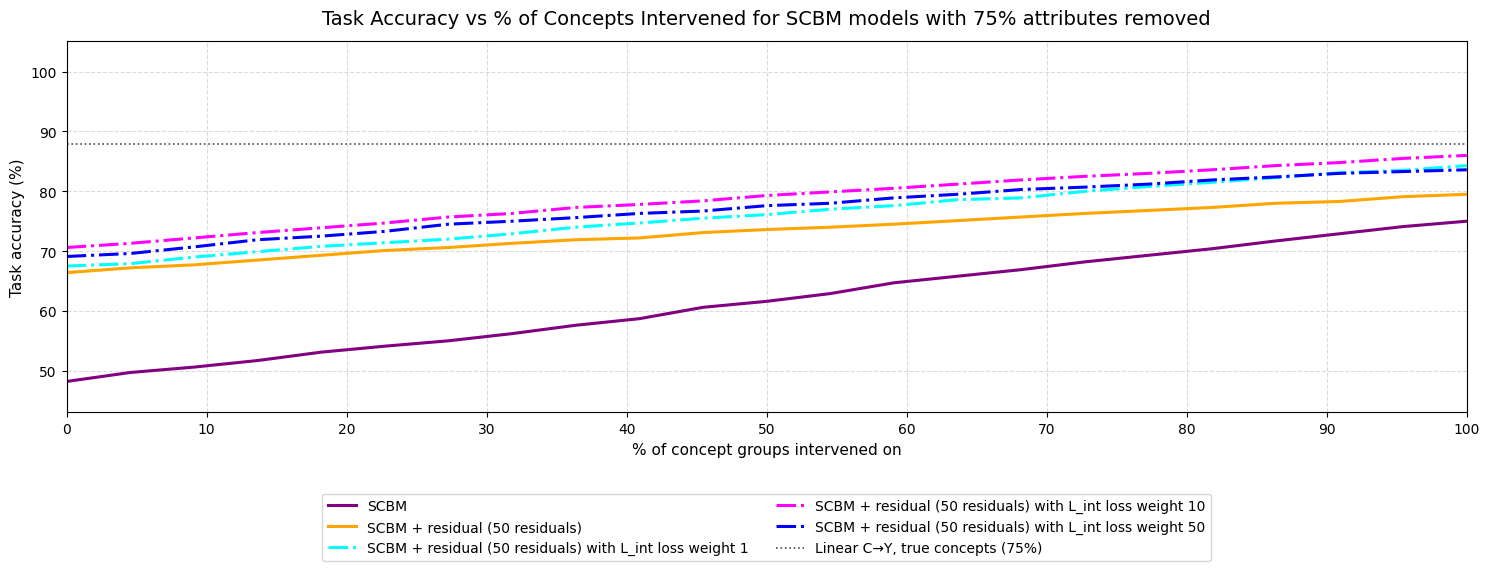

In [7]:

model_dir_scbm_075 = "Mateo_025_2026-05-06_14-14-58_11bb4"
model_dir_scbm_075_residual_50 = "Mateo_025_2026-05-06_15-22-45_878e2"

model_dir_scbm_075_residual_50_L_int_loss_1_fixed = "Mateo_025_fixed_L_int_loss_weight_1_2026-05-06_18-32-22_1fc60"
model_dir_scbm_075_residual_50_L_int_loss_10_fixed = "Mateo_025_fixed_L_int_loss_weight_10_2026-05-07_13-51-32_4209e"
model_dir_scbm_075_residual_50_L_int_loss_50_fixed = "Mateo_025_fixed_L_int_loss_weight_50_2026-05-07_20-21-56_16f65"






(concepts_intervened_list_scbm_075_residual_50_L_int_loss_10_fixed,
y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed, 
c_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed, 
c_auroc_list_scbm_075_residual_50_L_int_loss_10_fixed) = extract_info_from_intervention_log(model_dir_scbm_075_residual_50_L_int_loss_10_fixed, model_type="scbm_residual", return_c_auroc=True)

(concepts_intervened_list_scbm_075_residual_50_L_int_loss_1_fixed,
y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed, 
c_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed, 
c_auroc_list_scbm_075_residual_50_L_int_loss_1_fixed) = extract_info_from_intervention_log(model_dir_scbm_075_residual_50_L_int_loss_1_fixed, model_type="scbm_residual", return_c_auroc=True)

(concepts_intervened_list_scbm_075_residual_50_L_int_loss_50_fixed,
y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed, 
c_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed, 
c_auroc_list_scbm_075_residual_50_L_int_loss_50_fixed) = extract_info_from_intervention_log(model_dir_scbm_075_residual_50_L_int_loss_50_fixed, model_type="scbm_residual", return_c_auroc=True)

(concepts_intervened_list_scbm_075_residual_50,
y_accuracies_list_scbm_075_residual_50, 
c_accuracies_list_scbm_075_residual_50, 
c_auroc_list_scbm_075_residual_50) = extract_info_from_intervention_log(model_dir_scbm_075_residual_50, model_type="scbm_residual", return_c_auroc=True)



(concepts_intervened_list_scbm_075,
y_accuracies_list_scbm_075, 
c_accuracies_list_scbm_075, 
c_auroc_list_scbm_075) = extract_info_from_intervention_log(model_dir_scbm_075, model_type="scbm", return_c_auroc=True)

max_num_concepts_intervened = 22

concepts_intervened_pct_scbm_075 = [
    100.0 * c / max_num_concepts_intervened for c in concepts_intervened_list_scbm_075
]


concepts_intervened_pct_scbm_075_residual_50 = [
    100.0 * c / max_num_concepts_intervened for c in concepts_intervened_list_scbm_075_residual_50
]

concepts_intervened_pct_scbm_075_residual_50_L_int_loss_1_fixed = [
    100.0 * c / max_num_concepts_intervened for c in concepts_intervened_list_scbm_075_residual_50_L_int_loss_1_fixed
]

concepts_intervened_pct_scbm_075_residual_50_L_int_loss_10_fixed = [
    100.0 * c / max_num_concepts_intervened for c in concepts_intervened_list_scbm_075_residual_50_L_int_loss_10_fixed
]

concepts_intervened_pct_scbm_075_residual_50_L_int_loss_50_fixed = [
    100.0 * c / max_num_concepts_intervened for c in concepts_intervened_list_scbm_075_residual_50_L_int_loss_50_fixed
]







fig, ax = plt.subplots(figsize=(15, 6))



ax.plot(
    concepts_intervened_pct_scbm_075,
    y_accuracies_list_scbm_075,
    color = "purple",
    linewidth=2.2,
    markersize=6,
    label=r"SCBM",
)




ax.plot(
    concepts_intervened_pct_scbm_075_residual_50,
    y_accuracies_list_scbm_075_residual_50,
    color = "orange",
    linewidth=2.2,
    markersize=6,
    linestyle="-",
    label=r"SCBM + residual (50 residuals)",
)




ax.plot(
    concepts_intervened_pct_scbm_075_residual_50_L_int_loss_1_fixed,
    y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed,
    color = "cyan",
    linewidth=2.2,
    markersize=6,
    linestyle="-.",
    label=r"SCBM + residual (50 residuals) with L_int loss weight 1",
)  




ax.plot(
    concepts_intervened_pct_scbm_075_residual_50_L_int_loss_10_fixed,
    y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed,
    color = "magenta",
    linewidth=2.2,
    markersize=6,
    linestyle="-.",
    label=r"SCBM + residual (50 residuals) with L_int loss weight 10",
)

ax.plot(
    concepts_intervened_pct_scbm_075_residual_50_L_int_loss_50_fixed,
    y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed,
    color = "blue",
    linewidth=2.2,
    markersize=6,
    linestyle="-.",
    label=r"SCBM + residual (50 residuals) with L_int loss weight 50",
)



# y to c linear model accuracy

c_to_y_model_dir = os.path.join("experiments", "linear_head", "CUB")
c_to_y_025 = os.path.join(c_to_y_model_dir, "Mateo_025_2026-05-06_12-41-45_15c1b")

y_acc_c_to_y_025, _, _ = retrieve_acc_from_log(c_to_y_025, linear_model=True)

ax.axhline(
    y=y_acc_c_to_y_025,
    color="black",
    linestyle=":",
    linewidth=1.2,
    alpha=0.7,
    label=r"Linear C→Y, true concepts (75%)"
)





ax.set_title(
    "Task Accuracy vs % of Concepts Intervened for SCBM models with 75% attributes removed",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("% of concept groups intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=11))   
ax.set_xlim(0, 100)



y_min = min(min(y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed),
            min(y_accuracies_list_scbm_075), min(y_accuracies_list_scbm_075_residual_50), 
            min(y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed), 
            min(y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed),
            )

y_max = 100



pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)   

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,  # spread across columns
    frameon=True
)
fig.tight_layout()
plt.show()





In [8]:
df_dict = {
    "Model": [
        "SCBM",
        "SCBM + residual (50 residuals) without L_int loss",
        "SCBM + residual (50 residuals) with L_int loss weight 1",
        "SCBM + residual (50 residuals) with L_int loss weight 10",
        "SCBM + residual (50 residuals) with L_int loss weight 50",
    ],
    "Task accuracy (%) - 0 interventions": [y_accuracies_list_scbm_075[0],
        y_accuracies_list_scbm_075_residual_50[0],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed[0],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed[0],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed[0],
    ],
    "Task accuracy (%) - full interventions": [y_accuracies_list_scbm_075[-1],
        y_accuracies_list_scbm_075_residual_50[-1],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed[-1],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed[-1],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed[-1]],
    "Improvement (%)": [y_accuracies_list_scbm_075[-1] - y_accuracies_list_scbm_075[0],
        y_accuracies_list_scbm_075_residual_50[-1] - y_accuracies_list_scbm_075_residual_50[0], 
        y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed[-1] - y_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed[0],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed[-1] - y_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed[0],
        y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed[-1] - y_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed[0],
        ],
    "Concept AUROC (%) - 0 interventions": [c_auroc_list_scbm_075[0],
        c_auroc_list_scbm_075_residual_50[0],
        c_auroc_list_scbm_075_residual_50_L_int_loss_1_fixed[0],
        c_auroc_list_scbm_075_residual_50_L_int_loss_10_fixed[0],
        c_auroc_list_scbm_075_residual_50_L_int_loss_50_fixed[0],],
    "Concept Accuracy (%) - 0 interventions": [c_accuracies_list_scbm_075[0],
        c_accuracies_list_scbm_075_residual_50[0],
        c_accuracies_list_scbm_075_residual_50_L_int_loss_1_fixed[0],
        c_accuracies_list_scbm_075_residual_50_L_int_loss_10_fixed[0],
        c_accuracies_list_scbm_075_residual_50_L_int_loss_50_fixed[0],],
}

df_final_results_detailed_075 = pd.DataFrame(df_dict)

# Show full model names and allow wrapping onto multiple lines
pd.set_option("display.max_colwidth", None)
display(
    df_final_results_detailed_075.style
    .format(precision=2)
    .set_properties(
        subset=["Model"],
        **{"white-space": "normal", "max-width": "320px"}
    )
)

,Model,Task accuracy (%) - 0 interventions,Task accuracy (%) - full interventions,Improvement (%),Concept AUROC (%) - 0 interventions,Concept Accuracy (%) - 0 interventions
0,SCBM,48.20,75.00,26.80,97.00,94.50
1,SCBM + residual (50 residuals) without L_int loss,66.40,79.50,13.10,97.30,94.70
2,SCBM + residual (50 residuals) with L_int loss weight 1,67.50,84.30,16.80,97.20,94.70
3,SCBM + residual (50 residuals) with L_int loss weight 10,70.60,86.00,15.40,97.70,94.90
4,SCBM + residual (50 residuals) with L_int loss weight 50,69.10,83.60,14.50,97.10,94.10
